# 02 — Stratified Train/Val/Test Split

**Goal:** Partition the 10,015 ISIC 2018 images into three disjoint sets:
- **Train**: 70%
- **Validation**: 15%
- **Test**: 15%

**Method:** Stratified split — class proportions in the full dataset are preserved in each subset. This matters because the dataset is heavily imbalanced (NV = 67%, DF = 1.1%). A random (non-stratified) split could land zero DF samples in the test set.

**Output:** `data/processed/splits.csv` with columns `image`, `label`, `split`.
This file is committed to git so all experiments use the same partitions.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# Reproducibility — never change this seed once results are reported
SEED = 42

# Paths (relative to the project root, assuming you launch the notebook from notebooks/)
PROJECT_ROOT = Path("..").resolve()
LABELS_CSV   = PROJECT_ROOT / "data/raw/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv"
OUTPUT_DIR   = PROJECT_ROOT / "data/processed"
OUTPUT_CSV   = OUTPUT_DIR / "splits.csv"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Labels CSV exists:", LABELS_CSV.exists())
print("Output will go to:", OUTPUT_CSV)

Labels CSV exists: True
Output will go to: C:\Users\asus\Documents\skin cancer\data\processed\splits.csv


In [2]:
df = pd.read_csv(LABELS_CSV)
print("Raw CSV shape:", df.shape)
df.head()

Raw CSV shape: (10015, 8)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# idxmax picks the column name with the highest value (the 1) for each row
df['label'] = df[CLASS_NAMES].idxmax(axis=1)

# Keep only what we need
df = df[['image', 'label']].copy()

print(df.head())
print("\nClass counts:")
print(df['label'].value_counts())

          image label
0  ISIC_0024306    NV
1  ISIC_0024307    NV
2  ISIC_0024308    NV
3  ISIC_0024309    NV
4  ISIC_0024310   MEL

Class counts:
label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


In [4]:
# Stage 1: separate test (15%) from the rest (85%)
df_trainval, df_test = train_test_split(
    df,
    test_size=0.15,
    stratify=df['label'],
    random_state=SEED,
)

# Stage 2: split the remaining 85% into train and val
# We want val = 15% of the ORIGINAL data, which is 15/85 ≈ 17.65% of df_trainval
val_relative = 0.15 / 0.85

df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_relative,
    stratify=df_trainval['label'],
    random_state=SEED,
)

print(f"Train: {len(df_train):>5}  ({len(df_train)/len(df):.1%})")
print(f"Val:   {len(df_val):>5}  ({len(df_val)/len(df):.1%})")
print(f"Test:  {len(df_test):>5}  ({len(df_test)/len(df):.1%})")
print(f"Total: {len(df_train) + len(df_val) + len(df_test):>5}")

Train:  7009  (70.0%)
Val:    1503  (15.0%)
Test:   1503  (15.0%)
Total: 10015


## Two-stage stratified split

`sklearn.train_test_split` only splits into two sets at a time, so we do it in two stages:

1. **Stage 1:** peel off 15% as the test set
2. **Stage 2:** from the remaining 85%, peel off another chunk for validation (sized so val ends up at 15% of the *original* total)

`stratify=df['label']` is the key argument — it preserves the class proportions in every split. This is essential here because DF has only 115 samples; a non-stratified split could land 0 of them in test.

In [5]:
df_train = df_train.assign(split='train')
df_val   = df_val.assign(split='val')
df_test  = df_test.assign(split='test')

splits_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Sanity checks — catch the bugs most likely to silently break things
assert len(splits_df) == len(df), "Row count changed!"
assert splits_df['image'].is_unique, "Duplicate images across splits!"
assert set(splits_df['split']) == {'train', 'val', 'test'}, "Unexpected split labels"

print("All sanity checks passed")
print(f"Total rows: {len(splits_df)}")
splits_df.head()

All sanity checks passed
Total rows: 10015


,image,label,split
0,ISIC_0032407,NV,train
1,ISIC_0029583,NV,train
2,ISIC_0027505,NV,train
3,ISIC_0024719,NV,train
4,ISIC_0031456,NV,train


In [6]:
proportions = (
    splits_df
    .groupby('split')['label']
    .value_counts(normalize=True)   # normalize=True gives proportions, not raw counts
    .unstack()                       # pivot labels from rows into columns
    .reindex(columns=CLASS_NAMES)    # consistent class order (matches your EDA)
    .loc[['train', 'val', 'test']]   # consistent split order
)

print("Class proportions per split (%):")
print((proportions * 100).round(2))

Class proportions per split (%):
label    MEL     NV   BCC  AKIEC    BKL    DF  VASC
split                                              
train  11.11  66.96  5.14   3.27  10.97  1.14  1.41
val    11.11  66.93  5.12   3.26  10.98  1.20  1.40
test   11.11  66.93  5.12   3.26  10.98  1.13  1.46


In [8]:
counts = (
    splits_df
    .groupby('split')['label']
    .value_counts()
    .unstack()
    .reindex(columns=CLASS_NAMES)
    .loc[['train', 'val', 'test']]
)

print("Class counts per split:")
print(counts)

Class counts per split:
label  MEL    NV  BCC  AKIEC  BKL  DF  VASC
split                                      
train  779  4693  360    229  769  80    99
val    167  1006   77     49  165  18    21
test   167  1006   77     49  165  17    22


## Stratification verified

**Class proportions are preserved across all three splits** — every class appears in the same ~ratio in train, val, and test (e.g. NV ≈ 67% everywhere, DF ≈ 1.1% everywhere).

**No empty cells** — even the rarest class (DF) has at least 17 images in test, which is enough to compute per-class recall and contribute to macro F1.

**Per-class test counts** (the numbers that will determine evaluation reliability):

| Class  | Test count | Notes |
|--------|-----------:|-------|
| NV     | 1006       | Plentiful — dominant class |
| MEL    | 167        | Good coverage |
| BKL    | 165        | Good coverage |
| BCC    | 77         | Adequate |
| AKIEC  | 49         | Limited — single misclassification = ~2% recall hit |
| VASC   | 22         | Sparse — recall estimates will be noisy |
| DF     | 17         | Sparse — recall estimates will be noisy |

 For VASC and DF, a difference of even 1–2 correctly classified images shifts per-class recall by 5–6 percentage points. This is **intrinsic** to the dataset size, not a flaw in the split — it's exactly why this project explores **generative augmentation** for the rare classes.

In [9]:
splits_df.to_csv(OUTPUT_CSV, index=False)
print(f" Saved {len(splits_df)} rows to:")
print(f"   {OUTPUT_CSV}")

# Reload to confirm the file is readable and unchanged
check = pd.read_csv(OUTPUT_CSV)
assert len(check) == len(splits_df), "Reload size mismatch!"
assert list(check.columns) == ['image', 'label', 'split'], "Reload column mismatch!"
print(f"Verified: reloaded {len(check)} rows with columns {list(check.columns)}")

check.head()

 Saved 10015 rows to:
   C:\Users\asus\Documents\skin cancer\data\processed\splits.csv
Verified: reloaded 10015 rows with columns ['image', 'label', 'split']


,image,label,split
0,ISIC_0032407,NV,train
1,ISIC_0029583,NV,train
2,ISIC_0027505,NV,train
3,ISIC_0024719,NV,train
4,ISIC_0031456,NV,train


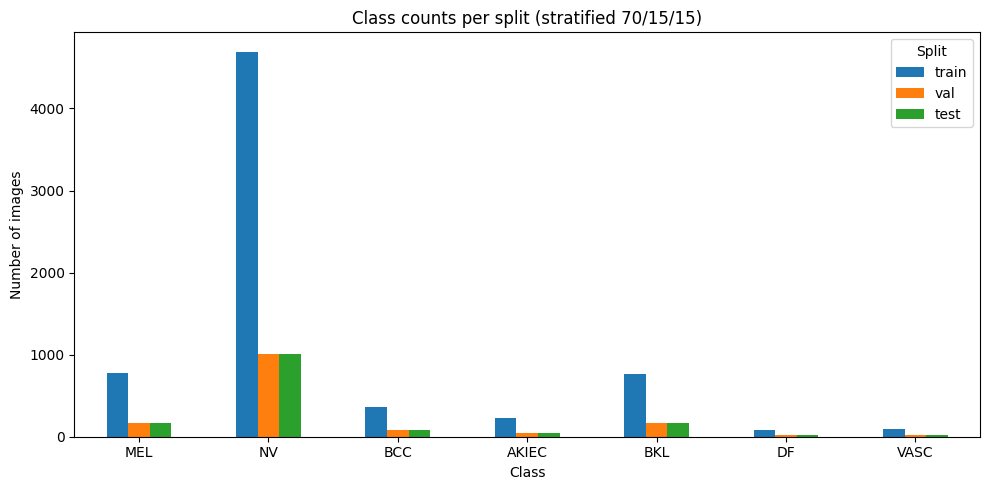

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
counts.T.plot(kind='bar', ax=ax)

ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_title("Class counts per split (stratified 70/15/15)")
ax.legend(title="Split")
plt.xticks(rotation=0)
plt.tight_layout()


results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
plt.savefig(results_dir / "split_distribution.png", dpi=120)
plt.show()

## Summary

- **Split:** stratified 70/15/15 using `sklearn.train_test_split` with `random_state=42`
- **Output:** `data/processed/splits.csv` (committed to git — all experiments use these exact partitions)
- **Verified:** class proportions preserved across all three splits, no empty cells, all 10,015 rows accounted for
- **Next step:** build `src/dataset.py` — a PyTorch `Dataset` class that loads images using this splits CSV